**Task 2 - Create a K-means clustering algorithm to group customers of a retail store based on their purchase history.**

**STEP 1 — Import Libraries**

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans

**STEP 2 — Uploading files**

In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers.csv


**STEP 3 — Load Dataset**

In [3]:
# Load dataset
df = pd.read_csv('/content/Mall_Customers.csv')

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


**STEP 4 — Display Dataset Information**

In [4]:
print("\n========== FIRST 5 ROWS ==========\n")

print(df.head())

print("\n========== DATASET SHAPE ==========\n")

print(df.shape)

print("\n========== DATASET INFO ==========\n")

print(df.info())


========== FIRST 5 ROWS ==========

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

========== DATASET SHAPE ==========

(200, 5)

========== DATASET INFO ==========

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-

**STEP 5 — Check Missing Values**

In [5]:
print("\n========== MISSING VALUES ==========\n")

print(df.isnull().sum())


========== MISSING VALUES ==========

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


**STEP 6 — Statistical Summary**

In [6]:
print("\n========== STATISTICAL SUMMARY ==========\n")

print(df.describe())


========== STATISTICAL SUMMARY ==========

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


**STEP 7 — Select Features for Clustering**

we'll use:


*   Annual Income

*   Spending Score



In [7]:
X = df.iloc[:, [3, 4]].values

print(X[:5])

[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


**STEP 8 — Find Optimal Number of Clusters (Elbow Method)**


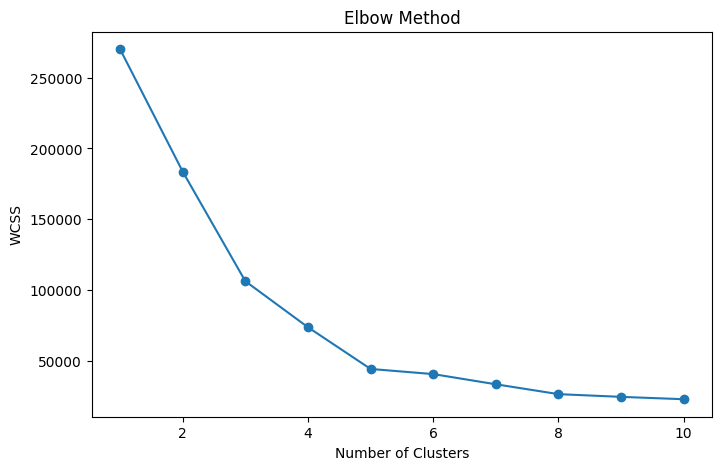

In [8]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.show()

**STEP 9 — Train K-Means Model**

We’ll use:

5 clusters

In [9]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

print("K-Means Model Trained Successfully!")

K-Means Model Trained Successfully!


**STEP 10 — Display Cluster Centers**

In [10]:
print("\n========== CLUSTER CENTERS ==========\n")

print(kmeans.cluster_centers_)


========== CLUSTER CENTERS ==========

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


**STEP 11 — Professional Customer Segmentation Visualization**

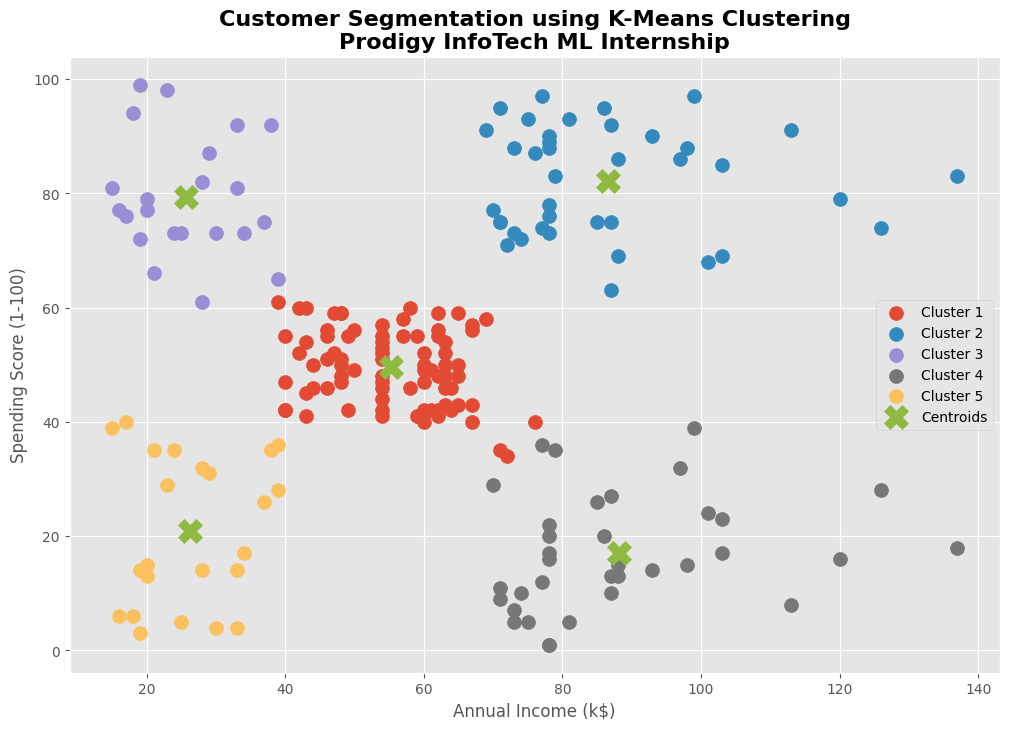

In [11]:
plt.style.use('ggplot')

plt.figure(figsize=(12,8))

# Cluster 1
plt.scatter(
    X[y_kmeans == 0, 0],
    X[y_kmeans == 0, 1],
    s=100,
    label='Cluster 1'
)

# Cluster 2
plt.scatter(
    X[y_kmeans == 1, 0],
    X[y_kmeans == 1, 1],
    s=100,
    label='Cluster 2'
)

# Cluster 3
plt.scatter(
    X[y_kmeans == 2, 0],
    X[y_kmeans == 2, 1],
    s=100,
    label='Cluster 3'
)

# Cluster 4
plt.scatter(
    X[y_kmeans == 3, 0],
    X[y_kmeans == 3, 1],
    s=100,
    label='Cluster 4'
)

# Cluster 5
plt.scatter(
    X[y_kmeans == 4, 0],
    X[y_kmeans == 4, 1],
    s=100,
    label='Cluster 5'
)

# Centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.title(
    'Customer Segmentation using K-Means Clustering\nProdigy InfoTech ML Internship',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Annual Income (k$)')

plt.ylabel('Spending Score (1-100)')

plt.legend()

plt.show()

**STEP 12 — Additional Distribution Visualizations**

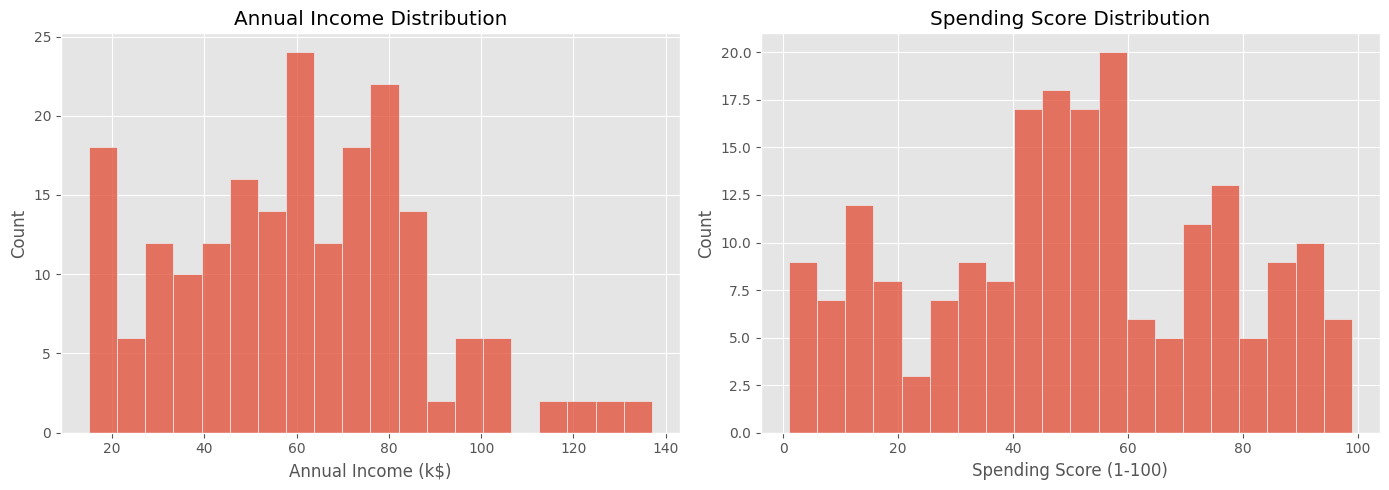

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Annual Income Distribution
sns.histplot(
    df['Annual Income (k$)'],
    bins=20,
    ax=axes[0]
)

axes[0].set_title('Annual Income Distribution')

# Spending Score Distribution
sns.histplot(
    df['Spending Score (1-100)'],
    bins=20,
    ax=axes[1]
)

axes[1].set_title('Spending Score Distribution')

plt.tight_layout()

plt.show()

**STEP 13 — Correlation Heatmap**

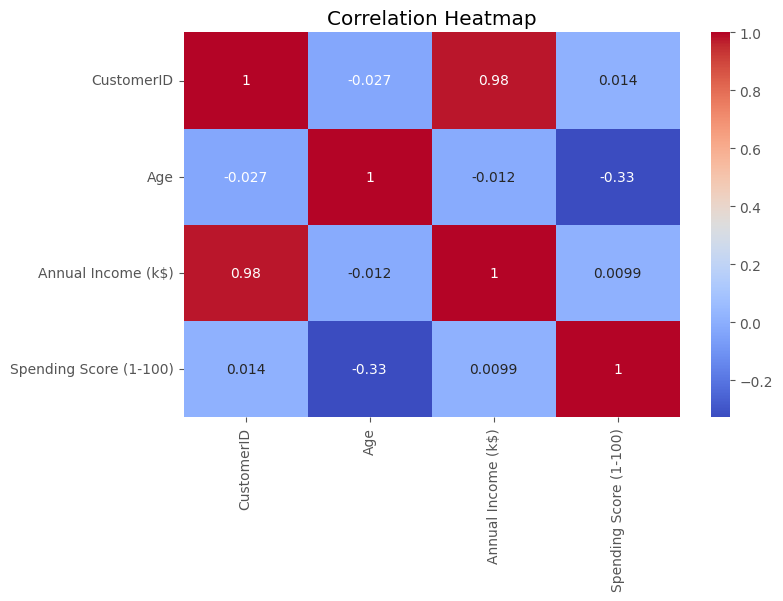

In [13]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**STEP 14 — Final Output Summary**

In [14]:
print("\n========== PROJECT SUMMARY ==========\n")

print("Algorithm Used: K-Means Clustering")

print("Number of Clusters: 5")

print("\nFeatures Used:")

print("- Annual Income")

print("- Spending Score")

print("\nTask Completed Successfully!")


========== PROJECT SUMMARY ==========

Algorithm Used: K-Means Clustering
Number of Clusters: 5

Features Used:
- Annual Income
- Spending Score

Task Completed Successfully!
